# RSM338 Assignment 6 Part A: Classification
## March 25, 2026
### Ethan Wang, Kevin Yang

## 1. Data Preparation (Reused from Assignment 5)

In [50]:
# Load in the data
import pandas as pd

df = pd.read_excel('lending_clubFull_Data_Set.xlsx')
df

,Unnamed: 0,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,0,263591,545710,20000.0,60 months,17.93,342.94,E,E5,Wylie ISD,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
1,1,1613916,69664096,30000.0,36 months,11.99,996.29,C,C1,Sergeant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
2,2,818934,8965180,21500.0,36 months,11.99,714.01,B,B3,Designer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
3,3,1606612,70572960,10000.0,36 months,13.67,340.18,C,C3,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
4,4,1639932,68589517,5000.0,36 months,8.49,157.82,B,B1,Sr. Manufacturing Engineer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,901888,4974773,10500.0,36 months,10.16,339.60,B,B1,Schneider Electric,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24996,24996,945413,1279809,12000.0,36 months,14.33,412.06,C,C1,Clark County School District,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24997,24997,366944,63496281,25000.0,36 months,12.69,838.63,C,C2,sales consultant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24998,24998,1043529,98124387,12200.0,60 months,13.49,280.66,C,C2,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN


Now that we loaded the data, we must  choose useful features for our analysis. As stated, many of the columns are redundant, so we should try to make our dataset more managable before our analysis.

### 1.1 Defining the Target Variable
We need a binary outcome for the loans - default or not - but we are given several outcomes. Let's first see all the unique loan outcomes.

In [51]:
# Display all unique values in the 'loan_status' column
unique_loan_status = df['loan_status'].unique()
unique_loan_status

<StringArray>
[                                        'Charged Off',
                                             'Current',
                                          'Fully Paid',
                                  'Late (31-120 days)',
                                     'In Grace Period',
                                   'Late (16-30 days)',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off',
                                             'Default',
                                                   nan]
Length: 10, dtype: str

We define default (1) as loans with statuses of 'Charged Off', 'Default', or 'Late (31-120 days)'. From a lender's perspective, 'Charged Off' represents a material loss where the debt is unlikely to be collected. We include 'Late (31-120 days)' as a functional default because statistically, loans that fall this far behind have a very low probability of returning to 'Current' status, essentially representing a total loss of expected cash flow. The rest of the outcomes are either paid off, being paid on time, or still recoverable, and are represented as in good standing (0)

### 1.2 Selecting Features
While selecting the features, we made sure to find features that are backwards looking and can tell us about the relevant credit characteristics of the borrower.

'fico_range_low' and 'sub_grade' provide a verified snapshot of the borrower's credit history at the exact moment of their application. These features are "crystallized" from the time of origination, making them highly reliable for predicting risk without including information from the future.

'annual_inc' (annual income) and 'dti' (monthly debt-to-income ratio) tell us about the earning power of the borrower. Even if a borrower faces unfortunate circumstances, a strong basis for their ability to repay suggests the debt can be recovered over time.

'home_ownership' (ownership status) and 'emp_length' (tenure in years) tell us if the borrower has a stable life. Borrowers with stability in their housing and employment will have much more predictable repayments compared to those who are frequently moving or job-hopping.

'loan_amnt' (the amount applied for) tells us about the overall burden of the loan on the borrower. It helps determine if the repayments are feasible relative to the borrower's perceived debt capacity and appetite for risk.


In [52]:
# SWAP: Removed 'num_accts_ever_120_pd' and 'pct_tl_nvr_dlq'
# ADDED: 'fico_range_low'
features_to_use = [
    'annual_inc', 'dti', 'loan_amnt', 'emp_length', 
    'home_ownership', 'fico_range_low', 'sub_grade','loan_status'
]

### 1.3 Handling Missing Values and Data Types 

In [71]:
# How many missing values are there in each of the features we want to use?
df[features_to_use].isna().sum()

annual_inc           1
dti                 12
loan_amnt            1
emp_length        1502
home_ownership       1
fico_range_low       1
sub_grade            1
loan_status          1
dtype: int64

In [72]:
# Handle missing values (Example: dropping rows with any NAs in selected features)
df_cleaned = df[features_to_use].dropna()
df_cleaned.isna().sum()

annual_inc        0
dti               0
loan_amnt         0
emp_length        0
home_ownership    0
fico_range_low    0
sub_grade         0
loan_status       0
dtype: int64

Theoretically, no applicant should have missing values in any of the columns. We choose to handle missing values by dropping values, instead of imputation. This is because we have over 25,000 observations, and the only significant feature with a lot of missing values is *emp_length*, with 1,502 missing values. After dropping all missing values we would still have over 23,000 valid observations, which is approximately 94% of the original data. Given the large remaining sample size, we expect this data reduction to have minimal impact on our overall analysis.

In [55]:
# Display all unique values in the 'home_ownership' column
unique_home_status = df['home_ownership'].unique()
unique_home_status

<StringArray>
['MORTGAGE', 'RENT', 'OWN', 'ANY', 'OTHER', 'NONE', nan]
Length: 7, dtype: str

In [56]:
# Selecting categorical columns
categorical_cols = ['home_ownership', 'sub_grade']

# Perform One-Hot Encoding
# drop_first=True to avoid the "Dummy Variable Trap" 
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

df_cleaned.head()

,annual_inc,dti,loan_amnt,emp_length,fico_range_low,loan_status,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,...,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5
0,44304.0,18.47,20000.0,1 year,690.0,Charged Off,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,136000.0,20.63,30000.0,10+ years,670.0,Current,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,50000.0,29.62,21500.0,1 year,735.0,Fully Paid,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,88000.0,5.32,5000.0,10+ years,660.0,Current,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,38500.0,33.73,16150.0,10+ years,660.0,Charged Off,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


We decided to encode home ownership status to have dummies for each status. While it would have been possible to assign a number to each status, we felt that it would hurt the interpretability of the variable, as there is no clear ranking for types of ownership. Many applicants would be unfairly hurt by a ranking of ownership, as renting versus owning have different trade-offs for individuals that may not be income related. Therefore, we feel it is unfair to rank the ownership, and multiple dummies would provide better interpretability and predictive power.

We also decided to one-hot encode subgrade assigned by the LC, as trying to rank would misrepresent the jump from one sub-grade to the next. For example, the difference in credit risk from A2 to A3 may be very different from F4 to F5. Therefore, we believe that one-hot encoding would allow the model to make its own predictions without any biases that may result from trying to linearly rank the subgrades.

In [57]:
# Create the mapping dictionary based on the dataset categories
emp_map = {
    '< 1 year': 0, 
    '1 year': 1, 
    '2 years': 2, 
    '3 years': 3, 
    '4 years': 4,
    '5 years': 5, 
    '6 years': 6, 
    '7 years': 7, 
    '8 years': 8, 
    '9 years': 9, 
    '10+ years': 10
}

# Apply it to the 'emp_length' column
df_cleaned['emp_length'] = df_cleaned['emp_length'].map(emp_map)

# Check the result - it should now be 0.0 to 10.0
print(df_cleaned['emp_length'].value_counts())

emp_length
10    8366
2     2243
3     1985
0     1941
1     1604
4     1509
5     1478
6     1225
8     1086
7     1072
9      988
Name: count, dtype: int64


For employment length, we decided to map the data type to integers. We chose to assign '< 1 year' to 0, and '10+ years' to 10. We believe that this is the most logical ranking for employment length, as it keeps the integer values in the original dataset, while providing intuitive values for the non-integer values.

In [58]:
# Define which categories count as Default (1)
# Everything else will be Repaid (0)
default_categories = [
    'Charged Off', 
    'Default', 
    'Late (31-120 days)', 
    'Does not meet the credit policy. Status:Charged Off'
]

# Create the binary target column
df_cleaned['default'] = df_cleaned['loan_status'].apply(lambda x: 1 if x in default_categories else 0)
df_cleaned.drop('loan_status', axis=1, inplace=True)
df_cleaned.head()

,annual_inc,dti,loan_amnt,emp_length,fico_range_low,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,...,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,default
0,44304.0,18.47,20000.0,1,690.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
1,136000.0,20.63,30000.0,10,670.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
2,50000.0,29.62,21500.0,1,735.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,0
4,88000.0,5.32,5000.0,10,660.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
5,38500.0,33.73,16150.0,10,660.0,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,1


In [59]:
# Report the final dimensions of the cleaned dataset
print(f"Final dimensions after cleaning and encoding: {df_cleaned.shape}")

Final dimensions after cleaning and encoding: (23497, 45)


The dimensions of our dataset are now $23,497 \times 45$. It should be noted we had to drop the first dummies for the home ownership and subgrade columns to avoid the dummy variable trap. We also dropped the 'loan_status' now that it has been encoded as a dummy variable.

### 1.4 Splitting Training and Test Data, and Standardization

In [60]:
# Splitting the train/test sets
from sklearn.model_selection import train_test_split

X = df_cleaned.drop('default', axis=1)
y = df_cleaned['default']

# 1. First split: 20% goes to Test, 80% stays for (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=23, shuffle=True)

# 2. Second split: Of that 80%, we want 1/4 of it to be Validation (which is 20% of the original total)a
# 0.25 * 0.80 = 0.20
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=23, shuffle=True)

In [61]:
# Standardizing the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 1. Fit and transform the training data
# This calculates the mean/std ONLY from X_train
X_train_scaled = scaler.fit_transform(X_train)

# 2. Transform the validation data
# We use the mean/std from the training set here
X_val_scaled = scaler.transform(X_val)

# 3. Transform the test data
# We use the mean/std from the training set here
X_test_scaled = scaler.transform(X_test)

The data has now been split $60/20/20$ for training, validation, and testing respectively, and standardized so it can be converted into PyTorch tensors.

In [62]:
X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape

((14097, 44), (4700, 44), (4700, 44))

In [63]:
# %pip install torch

In [64]:
import torch

# Convert Features (X)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Convert Targets (y) - We need to reshape them to (n, 1) for the Neural Net
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# Explain rationale for three sets instead of two (validation set)...

## 2. Building and Training a Neural Network

Let's build the feed-forward neural network with the given criteria first.

In [65]:
import torch.nn as nn
import torch.optim as optim

# --- ADD THIS LINE TO FREEZE RANDOMNESS ---
torch.manual_seed(23)
# ------------------------------------------

class BaselineNet(nn.Module):
    def __init__(self, input_size):
        super(BaselineNet, self).__init__()
        # Two hidden layers with 64 neurons each
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.output(x))
        return x

# Initialize model, loss, and optimizer
input_dim = X_train_tensor.shape[1]
model = BaselineNet(input_dim)
criterion = nn.BCELoss() # Binary Cross-Entropy [cite: 49]
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam at 0.001 [cite: 50]

In [66]:
import copy

epochs = 500 # [cite: 52]
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_weights = None

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())
        
        # Track best weights [cite: 53]
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

Epoch [50/500], Train Loss: 0.3444, Val Loss: 0.3377
Epoch [100/500], Train Loss: 0.3321, Val Loss: 0.3264
Epoch [150/500], Train Loss: 0.3293, Val Loss: 0.3249
Epoch [200/500], Train Loss: 0.3271, Val Loss: 0.3236
Epoch [250/500], Train Loss: 0.3250, Val Loss: 0.3228
Epoch [300/500], Train Loss: 0.3225, Val Loss: 0.3224
Epoch [350/500], Train Loss: 0.3194, Val Loss: 0.3227
Epoch [400/500], Train Loss: 0.3156, Val Loss: 0.3248
Epoch [450/500], Train Loss: 0.3116, Val Loss: 0.3284
Epoch [500/500], Train Loss: 0.3069, Val Loss: 0.3331


In [67]:
# Report total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Trainable Parameters: {total_params}")
print(f"Number of Training Observations: {len(X_train_tensor)}")

# Comparison calculation
ratio = total_params / len(X_train_tensor)
print(f"Observations-to-Parameters Ratio: {1/ratio:.4f}")

Total Trainable Parameters: 7105
Number of Training Observations: 14097
Observations-to-Parameters Ratio: 1.9841


There 7,105 trainable parameters and 14,097 training observations. Ideally, we would want many more observations than trainable parameters in our model. Unfortuantely, in this case, an observation-to-parameters ratio of roughly 2 (1.98) tells us that our model is very dense. With so many parameters, the network is now able to fit a lot of the noise in the dataset, which increases the bias of our model's estimates. By plotting loss curves, we can better see how this is hurting the predicting power of the neural network.

### 2.2 Validation and Testing Loss Curves

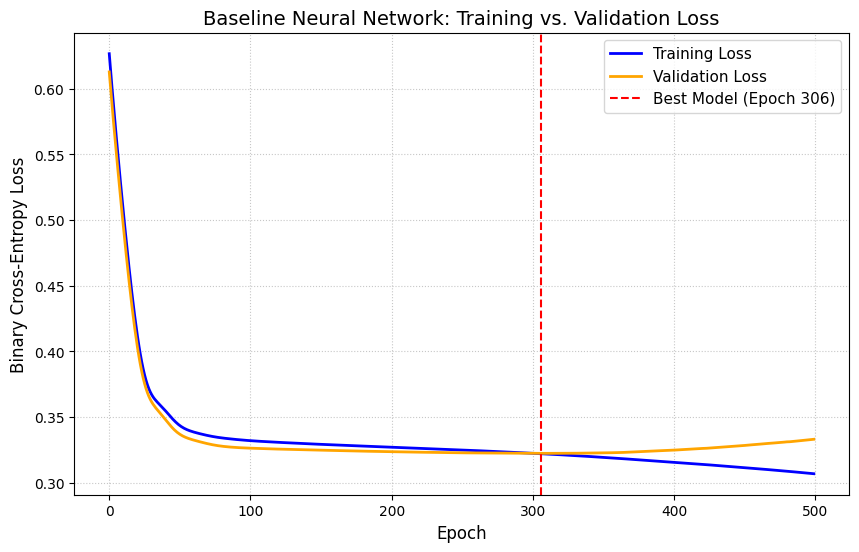

In [68]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)

# Based on your previous output, validation loss bottoms out around epoch 250-300
best_epoch = val_losses.index(min(val_losses))
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch})')

# Formatting
plt.title('Baseline Neural Network: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Display the plot
plt.show()

Looking at the loss curves, we can see that the Binary Cross-Entropy Loss is decreasing sharply and starts to plateau around epochs 50-100. After that, validation loss has already plateaued, while training loss continues to decrease very slowly. At epoch 309, our validation loss appears to be increasing, despite the decreasing training loss; this phenomenon is known as overfitting. Essentially, this means our neural network is no longer learning how and which indicators logically predict loan defaults, and starts fitting the noise by trying to "memorize" the results; kind of like trying to cheat on a test.

Test Accuracy: 0.8870
Test Recall: 0.0019
Test AUC: 0.6813


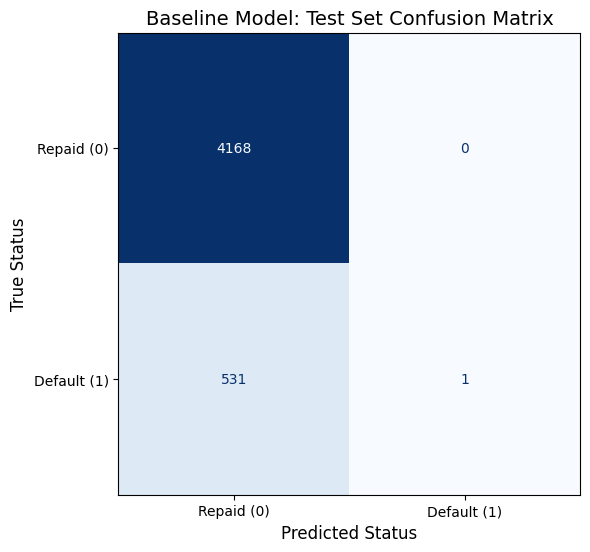

In [69]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Load the best weights from your training loop to ensure we use the pre-overfitting model
model.load_state_dict(best_model_weights)
model.eval()

# 2. Generate predictions on the unseen test set
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    # The output is a probability (due to Sigmoid). We use a standard 0.5 threshold for binary classification.
    test_predictions = (test_outputs >= 0.5).float()

# Convert PyTorch tensors back to NumPy arrays for sklearn compatibility
y_test_np = y_test_tensor.numpy()
test_preds_np = test_predictions.numpy()
test_probs_np = test_outputs.numpy() # AUC requires the raw probabilities, not the 0/1 classes

# 3. Calculate Core Metrics
accuracy = accuracy_score(y_test_np, test_preds_np)
recall = recall_score(y_test_np, test_preds_np)
auc = roc_auc_score(y_test_np, test_probs_np)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test AUC: {auc:.4f}")

# 4. Generate and Plot the Confusion Matrix
cm = confusion_matrix(y_test_np, test_preds_np)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Repaid (0)', 'Default (1)'])

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), colorbar=False)
plt.title('Baseline Model: Test Set Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Status', fontsize=12)
plt.ylabel('True Status', fontsize=12)
plt.grid(False)
plt.show()